<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/statistics/WorldStats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World energy statistics translated into NeqSim engineering scenarios

**Intended audience.** Process, energy, and data engineers who want to convert public
energy statistics into auditable gas-infrastructure calculations.

**Prerequisites.** Basic Python, descriptive statistics, thermodynamics, and process
flowsheets. The notebook is self-contained and runs in a clean Google Colab runtime.

## Learning objectives

After completing the tutorial, you can:

1. distinguish observations, rounded planning data, and engineering assumptions;
2. calculate weighted statistics, concentration, uncertainty, and data-quality checks;
3. represent a natural-gas mixture with the SRK equation of state in NeqSim;
4. convert annual standard-volume statistics into design-day mass flow;
5. connect `Stream`, `Compressor`, `Cooler`, and `Separator` objects in a
   `ProcessSystem`;
6. quantify pressure and electricity-supply sensitivities; and
7. communicate validity limits without presenting a teaching dataset as current data.


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-world-statistics")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )


The setup cell installs the current public-PyPI `neqsim` package only when it
is absent. Validation infrastructure may use a verified wheel snapshot, but the
notebook itself has no wheelhouse, repository checkout, or private-data dependency.


In [2]:
import platform
import subprocess
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import neqsim
from neqsim.process import clearProcess, compressor, cooler, separator, stream
from neqsim.thermo import TPflash, fluid

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "red": "#D55E00",
    "sky": "#56B4E9",
}

java_version = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            version("neqsim"),
            platform.python_version(),
            java_version,
        ],
    }
)
display(runtime_table)


,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


# Web sites with statistics

https://ourworldindata.org/energy#introduction

https://ec.europa.eu/eurostat/

https://www.bls.gov/bls/other.htm

https://www.ssb.no/en/

# Learn statistical analysis in Python

https://www.youtube.com/results?search_query=use+statistics+in+python&sp=CAM%253D


In [3]:
# @title Data Analysis with Python
# @markdown Introduction to data analysis with Python
from IPython.display import YouTubeVideo

YouTubeVideo("uOLxNrNk8", width=600, height=400)


Out[3]: <IPython.lib.display.YouTubeVideo at 0x7fa4834449e0>


## Preserved starting material and scope

The four original cells above are retained in their original order: the Colab badge,
the empty workspace cell now used for setup, the statistical-resource list, and the
introductory video. The original page contained no calculation, dataset, NeqSim model,
or technical figure.

This expansion does not reproduce the separate world oil-and-gas production tutorial.
Its focus is the **methodological bridge from statistics to a physical process design
case**.


## 1. Data contract: measured values versus planning assumptions

The compact table below is a **rounded, synthetic planning snapshot** with realistic
regional order of magnitude. It is deliberately embedded so execution does not depend
on a changing website. It must not be cited as an official historical series.

- `annual_gas_bcm` is a representative annual gas-volume scenario.
- `low_carbon_share_pct` and `upstream_intensity_kg_co2e_boe` are teaching assumptions.
- `confidence_score` records how strongly an analyst trusts each input, not a
  statistical probability.

For production work, replace these rows with a dated extract from the Energy Institute,
Our World in Data, Eurostat, or Statistics Norway and retain the source licence,
download date, units, and transformation log.


In [4]:
planning_data = pd.DataFrame(
    {
        "region": [
            "North America",
            "Europe",
            "Eurasia",
            "Asia Pacific",
            "Middle East",
            "Africa",
            "South & Central America",
        ],
        "annual_gas_bcm": [1000.0, 550.0, 650.0, 900.0, 600.0, 170.0, 160.0],
        "low_carbon_share_pct": [22.0, 42.0, 15.0, 19.0, 7.0, 24.0, 33.0],
        "upstream_intensity_kg_co2e_boe": [
            18.0,
            15.0,
            22.0,
            20.0,
            24.0,
            30.0,
            28.0,
        ],
        "confidence_score": [0.90, 0.95, 0.80, 0.85, 0.75, 0.65, 0.70],
    }
)

planning_data


Out[4]: 
                    region  ...  confidence_score
0            North America  ...              0.90
1                   Europe  ...              0.95
2                  Eurasia  ...              0.80
3             Asia Pacific  ...              0.85
4              Middle East  ...              0.75
5                   Africa  ...              0.65
6  South & Central America  ...              0.70

[7 rows x 5 columns]


### Data-quality gates

Before calculating an average, check schema, missing values, signs, ranges, and units.
A clean table is not necessarily an accurate table: provenance and representativeness
remain engineering responsibilities.


In [5]:
required_columns = {
    "region",
    "annual_gas_bcm",
    "low_carbon_share_pct",
    "upstream_intensity_kg_co2e_boe",
    "confidence_score",
}

assert required_columns.issubset(planning_data.columns)
assert planning_data["region"].is_unique
assert not planning_data[list(required_columns)].isna().any().any()
assert planning_data["annual_gas_bcm"].gt(0.0).all()
assert planning_data["low_carbon_share_pct"].between(0.0, 100.0).all()
assert planning_data["upstream_intensity_kg_co2e_boe"].gt(0.0).all()
assert planning_data["confidence_score"].between(0.0, 1.0).all()

quality_table = pd.DataFrame(
    {
        "Check": [
            "Rows",
            "Missing values",
            "Duplicate regions",
            "Scenario gas total",
        ],
        "Result": [
            len(planning_data),
            int(planning_data.isna().sum().sum()),
            int(planning_data["region"].duplicated().sum()),
            f"{planning_data['annual_gas_bcm'].sum():,.0f} bcm/year",
        ],
    }
)
display(quality_table)


,Check,Result
0,Rows,7
1,Missing values,0
2,Duplicate regions,0
3,Scenario gas total,"4,030 bcm/year"


## 2. Weighted statistics and concentration

A volume-weighted mean gives greater influence to regions with larger gas scenarios:

$$
\bar{x}_{w} = \frac{\sum_i w_i x_i}{\sum_i w_i}
$$

Here, $x_i$ is an intensity in kg CO₂e/boe and $w_i$ is annual gas volume in bcm/year.
The Herfindahl-Hirschman Index (HHI) summarizes concentration:

$$
HHI = \sum_i s_i^2
$$

The share $s_i$ is dimensionless and the HHI lies between $1/n$ and 1 for $n$ regions.
It is a concentration indicator, not a causal energy-security model.


In [6]:
volume_weights = planning_data["annual_gas_bcm"].to_numpy()
intensities = planning_data["upstream_intensity_kg_co2e_boe"].to_numpy()

weighted_intensity = np.average(intensities, weights=volume_weights)
weighted_variance = np.average(
    (intensities - weighted_intensity) ** 2,
    weights=volume_weights,
)
weighted_standard_deviation = np.sqrt(weighted_variance)
coefficient_of_variation = weighted_standard_deviation / weighted_intensity

regional_shares = volume_weights / volume_weights.sum()
hhi = np.sum(regional_shares**2)
effective_region_count = 1.0 / hhi

statistics_table = pd.DataFrame(
    {
        "Metric": [
            "Weighted intensity",
            "Weighted standard deviation",
            "Coefficient of variation",
            "HHI",
            "Effective region count",
        ],
        "Value": [
            weighted_intensity,
            weighted_standard_deviation,
            coefficient_of_variation,
            hhi,
            effective_region_count,
        ],
        "Unit": [
            "kg CO2e/boe",
            "kg CO2e/boe",
            "-",
            "-",
            "regions",
        ],
    }
)
display(statistics_table.round(4))


,Metric,Value,Unit
0,Weighted intensity,20.4789,kg CO2e/boe
1,Weighted standard deviation,3.7365,kg CO2e/boe
2,Coefficient of variation,0.1825,-
3,HHI,0.1816,-
4,Effective region count,5.5063,regions


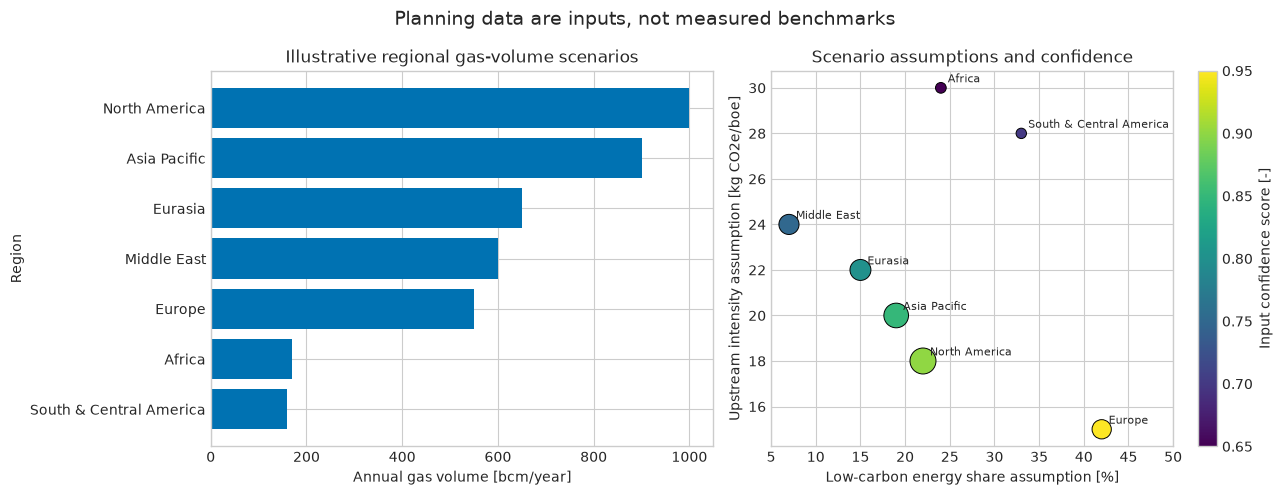

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5))

sorted_data = planning_data.sort_values("annual_gas_bcm")

axes[0].barh(
    sorted_data["region"],
    sorted_data["annual_gas_bcm"],
    color=COLORS["blue"],
)
axes[0].set_title("Illustrative regional gas-volume scenarios")
axes[0].set_xlabel("Annual gas volume [bcm/year]")
axes[0].set_ylabel("Region")

scatter = axes[1].scatter(
    planning_data["low_carbon_share_pct"],
    planning_data["upstream_intensity_kg_co2e_boe"],
    s=planning_data["annual_gas_bcm"] * 0.35,
    c=planning_data["confidence_score"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.7,
)
for row in planning_data.itertuples():
    axes[1].annotate(
        row.region,
        (row.low_carbon_share_pct, row.upstream_intensity_kg_co2e_boe),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )
axes[1].set_title("Scenario assumptions and confidence")
axes[1].set_xlabel("Low-carbon energy share assumption [%]")
axes[1].set_ylabel("Upstream intensity assumption [kg CO2e/boe]")
axes[1].set_xlim(5.0, 50.0)
colorbar = figure.colorbar(scatter, ax=axes[1])
colorbar.set_label("Input confidence score [-]")

figure.suptitle("Planning data are inputs, not measured benchmarks", fontsize=14)
figure.tight_layout()
plt.show()


The first figure makes the relative scale explicit. The second prevents an
analyst from confusing a smooth regression with causality: each point is an assumed
regional planning case, bubble area represents gas volume, and colour reports input
confidence. Confidence should affect review priority and uncertainty ranges.


### A transparent uncertainty illustration

Bootstrap resampling estimates how sensitive the weighted mean is to the small set of
regional cases. It does not account for systematic source bias, correlated errors, or
the fact that these rows are planning assumptions.


In [8]:
random_generator = np.random.default_rng(20260727)
bootstrap_means = []

for _ in range(5000):
    sampled_indices = random_generator.integers(
        low=0,
        high=len(planning_data),
        size=len(planning_data),
    )
    sampled_weights = volume_weights[sampled_indices]
    sampled_intensities = intensities[sampled_indices]
    sampled_mean = np.average(
        sampled_intensities,
        weights=sampled_weights,
    )
    bootstrap_means.append(sampled_mean)

bootstrap_means = np.asarray(bootstrap_means)
confidence_interval = np.quantile(bootstrap_means, [0.025, 0.975])

print(
    "Illustrative 95% bootstrap interval: "
    f"{confidence_interval[0]:.2f} to {confidence_interval[1]:.2f} kg CO2e/boe"
)


Illustrative 95% bootstrap interval: 18.26 to 23.61 kg CO2e/boe


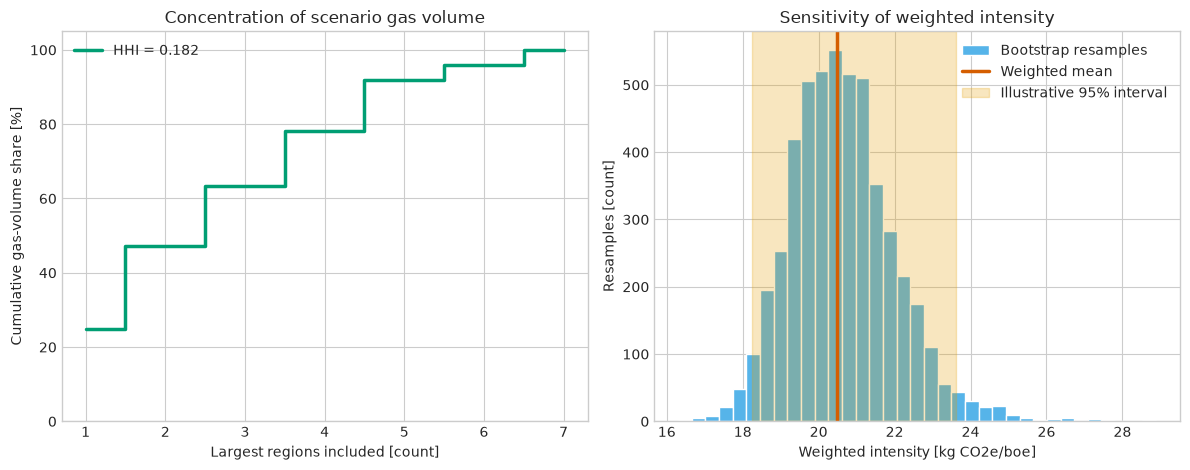

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ordered_shares = np.sort(regional_shares)[::-1]
cumulative_share = np.cumsum(ordered_shares)
region_count = np.arange(1, len(ordered_shares) + 1)

axes[0].step(
    region_count,
    cumulative_share * 100.0,
    where="mid",
    color=COLORS["green"],
    linewidth=2.5,
    label=f"HHI = {hhi:.3f}",
)
axes[0].set_title("Concentration of scenario gas volume")
axes[0].set_xlabel("Largest regions included [count]")
axes[0].set_ylabel("Cumulative gas-volume share [%]")
axes[0].set_ylim(0.0, 105.0)
axes[0].legend()

axes[1].hist(
    bootstrap_means,
    bins=35,
    color=COLORS["sky"],
    edgecolor="white",
    label="Bootstrap resamples",
)
axes[1].axvline(
    weighted_intensity,
    color=COLORS["red"],
    linewidth=2.5,
    label="Weighted mean",
)
axes[1].axvspan(
    confidence_interval[0],
    confidence_interval[1],
    color=COLORS["orange"],
    alpha=0.25,
    label="Illustrative 95% interval",
)
axes[1].set_title("Sensitivity of weighted intensity")
axes[1].set_xlabel("Weighted intensity [kg CO2e/boe]")
axes[1].set_ylabel("Resamples [count]")
axes[1].legend()

figure.tight_layout()
plt.show()


## 3. Represent the traded gas in NeqSim

The statistics report standard volume, while equipment is governed by mass, pressure,
temperature, composition, and phase behaviour. NeqSim represents the gas as a
thermodynamic system. The Soave-Redlich-Kwong (SRK) equation of state is appropriate
for this dry, non-associating screening gas; water-rich or acid-gas systems may require
CPA or another validated model.

Composition is an explicit assumption. The model includes methane, ethane, propane,
nitrogen, and CO₂. NeqSim performs the TP flash and supplies standard density, molar
mass, compressibility, heat capacity, and transport properties.


In [10]:
gas_composition = {
    "methane": 0.920,
    "ethane": 0.045,
    "propane": 0.015,
    "nitrogen": 0.010,
    "CO2": 0.010,
}

assert np.isclose(sum(gas_composition.values()), 1.0, atol=1.0e-12)

reference_gas = fluid("srk")
for component_name, mole_fraction in gas_composition.items():
    reference_gas.addComponent(component_name, mole_fraction)

reference_gas.setMixingRule("classic")
reference_gas.setTemperature(15.0, "C")
reference_gas.setPressure(1.01325, "bara")
TPflash(reference_gas)
reference_gas.initProperties()


In [11]:
standard_density_kg_m3 = reference_gas.getDensity("kg/m3")
molar_mass_kg_mol = reference_gas.getMolarMass("kg/mol")
compressibility_factor = reference_gas.getZ()
heat_capacity_kj_kg_k = reference_gas.getCp("kJ/kgK")

property_table = pd.DataFrame(
    {
        "Property": [
            "Standard density",
            "Molar mass",
            "Compressibility factor",
            "Heat capacity Cp",
        ],
        "Value": [
            standard_density_kg_m3,
            molar_mass_kg_mol,
            compressibility_factor,
            heat_capacity_kj_kg_k,
        ],
        "Unit": ["kg/Sm3", "kg/mol", "-", "kJ/(kg K)"],
    }
)
display(property_table.round(6))


,Property,Value,Unit
0,Standard density,0.741610,kg/Sm3
1,Molar mass,0.017494,kg/mol
2,Compressibility factor,0.997707,-
3,Heat capacity Cp,2.099850,kJ/(kg K)


## 4. Convert annual statistics to a design-day stream

Let $V_i$ be annual regional gas volume in bcm/year, $f_a$ the fraction assigned to
one representative facility, $A$ availability, and $\rho_s$ standard density in
kg/Sm³. The facility mass flow is:

$$
\dot{m}_i =
\frac{V_i 10^9 f_a \rho_s}{365 A \cdot 24}
$$

The result is in kg/h. This is a scale bridge, not a forecast: changing $f_a$ changes
asset size linearly.


In [12]:
asset_share = 0.0020
availability = 0.92

planning_data["design_volume_msm3_day"] = (
    planning_data["annual_gas_bcm"]
    * 1.0e9
    * asset_share
    / (365.0 * availability)
    / 1.0e6
)
planning_data["design_mass_kg_h"] = (
    planning_data["design_volume_msm3_day"]
    * 1.0e6
    * standard_density_kg_m3
    / 24.0
)

display(
    planning_data[
        [
            "region",
            "design_volume_msm3_day",
            "design_mass_kg_h",
        ]
    ].round(3)
)


,region,design_volume_msm3_day,design_mass_kg_h
0,North America,5.956,184040.625
1,Europe,3.276,101222.344
2,Eurasia,3.871,119626.406
3,Asia Pacific,5.360,165636.563
4,Middle East,3.574,110424.375
5,Africa,1.013,31286.906
6,South & Central America,0.953,29446.500


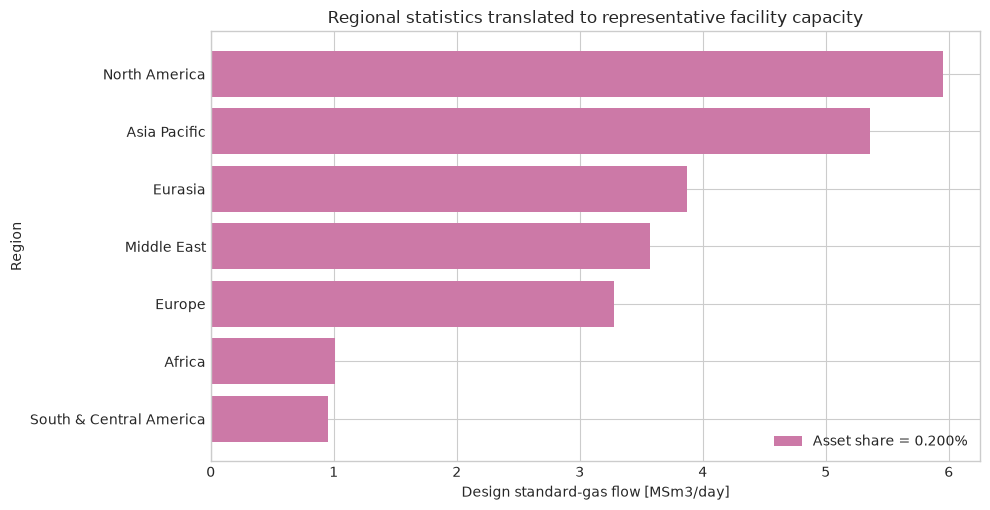

In [13]:
figure, axis = plt.subplots(figsize=(10, 5.2))

ordered = planning_data.sort_values("design_volume_msm3_day")
axis.barh(
    ordered["region"],
    ordered["design_volume_msm3_day"],
    color=COLORS["purple"],
    label=f"Asset share = {asset_share:.3%}",
)
axis.set_title("Regional statistics translated to representative facility capacity")
axis.set_xlabel("Design standard-gas flow [MSm3/day]")
axis.set_ylabel("Region")
axis.legend()

figure.tight_layout()
plt.show()


## 5. Connected compression workflow

The practical application receives dry gas at 35 bara and 25 °C, compresses it,
intercools to 30 °C, and removes any equilibrium liquid in a scrubber.

- `Stream` carries the thermodynamic state and mass flow.
- `Compressor` solves an adiabatic-efficiency specification.
- `Cooler` imposes the aftercooler outlet temperature and reports duty.
- `Separator` exposes phase-specific product streams.
- `ProcessSystem` executes the connected objects in dependency order.

The simplified shaft-power relationship explains the expected trend:

$$
\dot{W} \propto
\frac{\dot{m}}{\eta_s}
\left[
\left(\frac{p_2}{p_1}\right)^{(k-1)/k} - 1
\right]
$$

Here, $\dot{W}$ is power in kW, $\dot{m}$ is mass flow in kg/s, $\eta_s$ is
isentropic efficiency, and $p_2/p_1$ is pressure ratio. NeqSim calculates properties
and enthalpy changes rather than using this constant-$k$ approximation.


In [14]:
def run_export_compression(
    standard_flow_msm3_day,
    outlet_pressure_bara,
    isentropic_efficiency=0.78,
):
    clearProcess()
    process_gas = reference_gas.clone()

    feed = stream("statistics-derived feed", process_gas)
    feed.setFlowRate(standard_flow_msm3_day, "MSm3/day")
    feed.setTemperature(25.0, "C")
    feed.setPressure(35.0, "bara")

    export_compressor = compressor("export compressor", feed)
    export_compressor.setOutletPressure(outlet_pressure_bara, "bara")
    export_compressor.setIsentropicEfficiency(isentropic_efficiency)

    aftercooler = cooler(
        "export aftercooler",
        export_compressor.getOutletStream(),
    )
    aftercooler.setOutTemperature(30.0, "C")

    export_scrubber = separator(
        "export scrubber",
        aftercooler.getOutletStream(),
    )

    process = neqsim.jneqsim.process.processmodel.ProcessSystem()
    for unit_operation in [
        feed,
        export_compressor,
        aftercooler,
        export_scrubber,
    ]:
        process.add(unit_operation)

    process.run()

    inlet_mass_kg_h = feed.getFlowRate("kg/hr")
    gas_mass_kg_h = export_scrubber.getGasOutStream().getFlowRate("kg/hr")
    liquid_mass_kg_h = export_scrubber.getLiquidOutStream().getFlowRate("kg/hr")
    mass_residual = (
        gas_mass_kg_h + liquid_mass_kg_h - inlet_mass_kg_h
    ) / inlet_mass_kg_h

    return {
        "process": process,
        "feed": feed,
        "compressor": export_compressor,
        "cooler": aftercooler,
        "separator": export_scrubber,
        "standard_flow_msm3_day": standard_flow_msm3_day,
        "outlet_pressure_bara": outlet_pressure_bara,
        "inlet_mass_kg_h": inlet_mass_kg_h,
        "gas_mass_kg_h": gas_mass_kg_h,
        "liquid_mass_kg_h": liquid_mass_kg_h,
        "mass_residual": mass_residual,
        "power_kw": export_compressor.getPower("kW"),
        "cooler_duty_kw": aftercooler.getDuty("kW"),
        "outlet_temperature_c": (
            export_scrubber.getGasOutStream().getTemperature("C")
        ),
    }


In [15]:
base_flow_msm3_day = planning_data.loc[
    planning_data["region"] == "Europe",
    "design_volume_msm3_day",
].iloc[0]

base_case = run_export_compression(
    standard_flow_msm3_day=base_flow_msm3_day,
    outlet_pressure_bara=100.0,
)

base_result_table = pd.DataFrame(
    {
        "Quantity": [
            "Standard flow",
            "Inlet mass flow",
            "Outlet pressure",
            "Compressor power",
            "Aftercooler duty",
            "Gas product flow",
            "Liquid product flow",
            "Normalized mass residual",
        ],
        "Value": [
            base_case["standard_flow_msm3_day"],
            base_case["inlet_mass_kg_h"],
            base_case["outlet_pressure_bara"],
            base_case["power_kw"],
            base_case["cooler_duty_kw"],
            base_case["gas_mass_kg_h"],
            base_case["liquid_mass_kg_h"],
            base_case["mass_residual"],
        ],
        "Unit": [
            "MSm3/day",
            "kg/h",
            "bara",
            "kW",
            "kW",
            "kg/h",
            "kg/h",
            "-",
        ],
    }
)
display(base_result_table.round(6))


,Quantity,Value,Unit
0,Standard flow,3.275759,MSm3/day
1,Inlet mass flow,100986.572948,kg/h
2,Outlet pressure,100.000000,bara
3,Compressor power,5714.683365,kW
4,Aftercooler duty,-7310.352280,kW
5,Gas product flow,100986.572948,kg/h
6,Liquid product flow,0.000000,kg/h
7,Normalized mass residual,0.000000,-


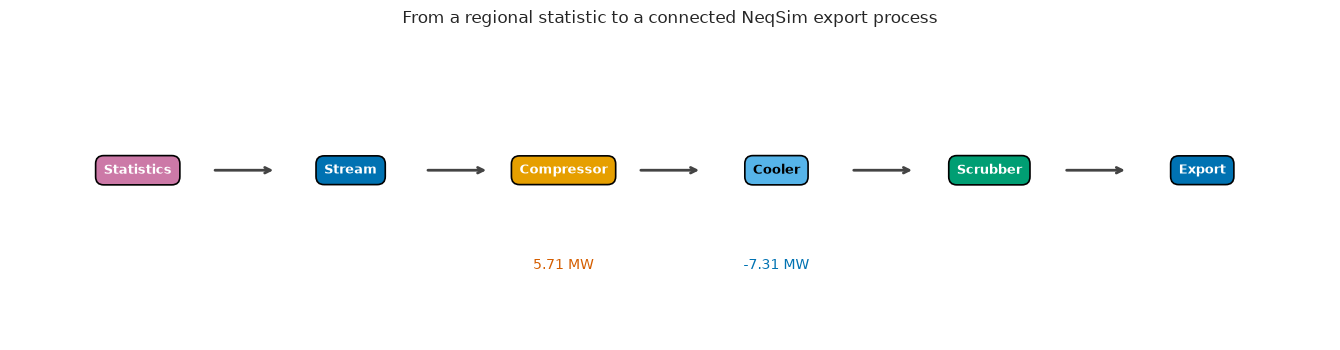

In [16]:
figure, axis = plt.subplots(figsize=(13.5, 3.6))

unit_names = ["Statistics", "Stream", "Compressor", "Cooler", "Scrubber", "Export"]
unit_positions = np.arange(len(unit_names))
unit_colors = [
    COLORS["purple"],
    COLORS["blue"],
    COLORS["orange"],
    COLORS["sky"],
    COLORS["green"],
    COLORS["blue"],
]

for index, unit_name in enumerate(unit_names):
    axis.text(
        index,
        0.0,
        unit_name,
        ha="center",
        va="center",
        color="white" if unit_name != "Cooler" else "black",
        fontsize=9,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.65",
            "facecolor": unit_colors[index],
            "edgecolor": "black",
            "linewidth": 1.2,
        },
        zorder=3,
    )
    if index < len(unit_names) - 1:
        axis.annotate(
            "",
            xy=(index + 1 - 0.35, 0.0),
            xytext=(index + 0.35, 0.0),
            arrowprops={"arrowstyle": "->", "lw": 2.0, "color": "#444444"},
        )

axis.text(
    2,
    -0.32,
    f"{base_case['power_kw'] / 1000.0:.2f} MW",
    ha="center",
    color=COLORS["red"],
)
axis.text(
    3,
    -0.32,
    f"{base_case['cooler_duty_kw'] / 1000.0:.2f} MW",
    ha="center",
    color=COLORS["blue"],
)
axis.set_title("From a regional statistic to a connected NeqSim export process")
axis.set_xlim(-0.6, len(unit_names) - 0.4)
axis.set_ylim(-0.55, 0.45)
axis.axis("off")

figure.tight_layout()
plt.show()


The Europe planning row becomes a representative facility feed after applying
the stated asset-share and availability assumptions. The compressor power and cooler
duty are therefore **scenario results**, not regional totals. The dry-gas case remains
single phase after cooling, so the scrubber liquid flow should be negligible while the
total mass balance still closes.


In [17]:
assert 0.60 < standard_density_kg_m3 < 1.00
assert 0.016 < molar_mass_kg_mol < 0.022
assert 0.90 < compressibility_factor < 1.05
assert base_case["power_kw"] > 0.0
assert base_case["cooler_duty_kw"] < 0.0
assert abs(base_case["mass_residual"]) < 1.0e-10
assert base_case["liquid_mass_kg_h"] < 1.0e-6 * base_case["inlet_mass_kg_h"]

print("Base thermodynamic, sign, phase, and total-mass checks passed.")


Base thermodynamic, sign, phase, and total-mass checks passed.


## 6. Pressure and regional-scale sensitivity

The same reusable process function can screen pressures without hidden state. Each
case receives a fresh fluid and process graph. Specific power in kWh/Sm³ separates the
pressure effect from facility size and should increase with pressure ratio.


In [18]:
outlet_pressures_bara = np.array(
    [70.0, 85.0, 100.0, 115.0, 130.0, 145.0, 160.0]
)
pressure_rows = []

for outlet_pressure_bara in outlet_pressures_bara:
    pressure_case = run_export_compression(
        standard_flow_msm3_day=base_flow_msm3_day,
        outlet_pressure_bara=outlet_pressure_bara,
    )
    standard_flow_sm3_h = base_flow_msm3_day * 1.0e6 / 24.0
    specific_power_kwh_sm3 = (
        pressure_case["power_kw"] / standard_flow_sm3_h
    )
    pressure_rows.append(
        {
            "outlet_pressure_bara": outlet_pressure_bara,
            "power_kw": pressure_case["power_kw"],
            "cooler_duty_kw": pressure_case["cooler_duty_kw"],
            "specific_power_kwh_sm3": specific_power_kwh_sm3,
            "mass_residual": pressure_case["mass_residual"],
        }
    )

pressure_results = pd.DataFrame(pressure_rows)
pressure_results.round(6)


Out[18]: 
   outlet_pressure_bara     power_kw  ...  specific_power_kwh_sm3  mass_residual
0                  70.0  3597.083236  ...                0.026354            0.0
1                  85.0  4724.626429  ...                0.034615            0.0
2                 100.0  5714.683365  ...                0.041869            0.0
3                 115.0  6602.431713  ...                0.048373            0.0
4                 130.0  7410.816067  ...                0.054296            0.0
5                 145.0  8155.684200  ...                0.059753            0.0
6                 160.0  8848.468237  ...                0.064829            0.0

[7 rows x 5 columns]


In [19]:
regional_rows = []

for row in planning_data.itertuples():
    regional_case = run_export_compression(
        standard_flow_msm3_day=row.design_volume_msm3_day,
        outlet_pressure_bara=100.0,
    )
    regional_rows.append(
        {
            "region": row.region,
            "flow_msm3_day": row.design_volume_msm3_day,
            "power_mw": regional_case["power_kw"] / 1000.0,
            "mass_residual": regional_case["mass_residual"],
        }
    )

regional_results = pd.DataFrame(regional_rows)
regional_results.round(6)


Out[19]: 
                    region  flow_msm3_day   power_mw  mass_residual
0            North America       5.955926  10.390333            0.0
1                   Europe       3.275759   5.714683            0.0
2                  Eurasia       3.871352   6.753717            0.0
3             Asia Pacific       5.360334   9.351300            0.0
4              Middle East       3.573556   6.234200            0.0
5                   Africa       1.012507   1.766357            0.0
6  South & Central America       0.952948   1.662453            0.0


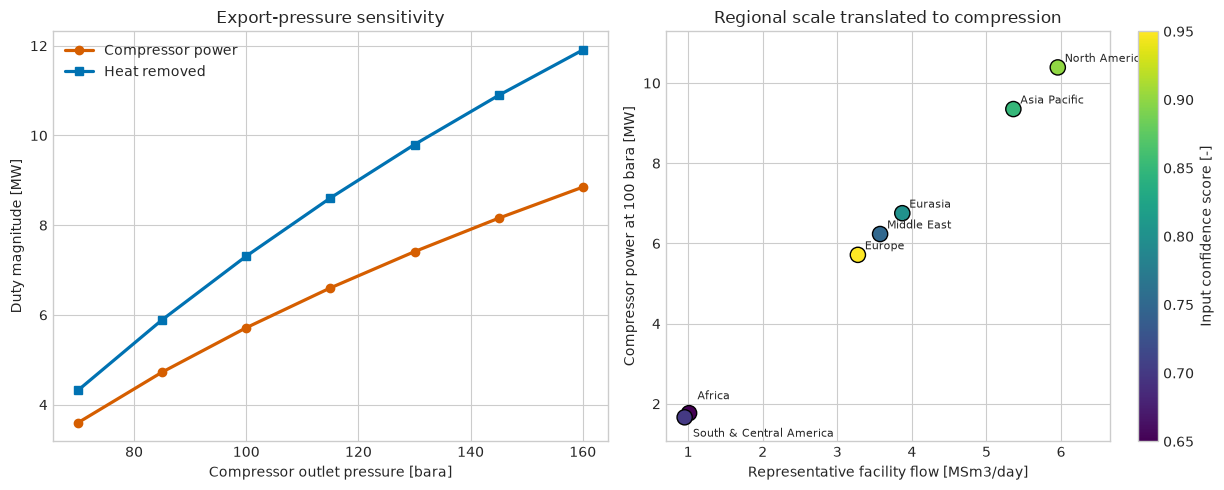

In [20]:
figure, axes = plt.subplots(1, 2, figsize=(12.5, 5))

axes[0].plot(
    pressure_results["outlet_pressure_bara"],
    pressure_results["power_kw"] / 1000.0,
    marker="o",
    color=COLORS["red"],
    linewidth=2.3,
    label="Compressor power",
)
axes[0].plot(
    pressure_results["outlet_pressure_bara"],
    -pressure_results["cooler_duty_kw"] / 1000.0,
    marker="s",
    color=COLORS["blue"],
    linewidth=2.3,
    label="Heat removed",
)
axes[0].set_title("Export-pressure sensitivity")
axes[0].set_xlabel("Compressor outlet pressure [bara]")
axes[0].set_ylabel("Duty magnitude [MW]")
axes[0].legend()

merged_results = regional_results.merge(
    planning_data[["region", "confidence_score"]],
    on="region",
)
regional_scatter = axes[1].scatter(
    merged_results["flow_msm3_day"],
    merged_results["power_mw"],
    s=120,
    c=merged_results["confidence_score"],
    cmap="viridis",
    edgecolor="black",
)
label_offsets = {
    "Africa": (6, 10),
    "South & Central America": (6, -14),
}
for row in merged_results.itertuples():
    offset = label_offsets.get(row.region, (5, 4))
    axes[1].annotate(
        row.region,
        (row.flow_msm3_day, row.power_mw),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
    )
axes[1].set_title("Regional scale translated to compression")
axes[1].set_xlabel("Representative facility flow [MSm3/day]")
axes[1].set_ylabel("Compressor power at 100 bara [MW]")
axes[1].set_xlim(
    0.7,
    merged_results["flow_msm3_day"].max() + 0.7,
)
axes[1].set_ylim(
    merged_results["power_mw"].min() - 0.6,
    merged_results["power_mw"].max() + 0.9,
)
regional_colorbar = figure.colorbar(
    regional_scatter,
    ax=axes[1],
)
regional_colorbar.set_label("Input confidence score [-]")

figure.tight_layout()
plt.show()


## 7. Electricity-source scenario

Operational electricity emissions are screened with:

$$
m_{\mathrm{CO_2e}} =
\dot{W} \, EF_{\mathrm{el}} \, t
$$

The emission factor $EF_{\mathrm{el}}$ is in kg CO₂e/kWh, power $\dot{W}$ is in kW,
and operating time $t$ is in hours/year. The factors below are explicit teaching
assumptions, not universal lifecycle benchmarks. Replace them with project-specific,
time-matched factors.


In [21]:
electricity_scenarios = pd.DataFrame(
    {
        "electricity_source": [
            "Gas-turbine generation",
            "Grid import",
            "Wind-backed supply",
        ],
        "emission_factor_kg_co2e_kwh": [0.42, 0.05, 0.012],
    }
)

operating_hours_year = 8760.0 * availability
electricity_scenarios["annual_emissions_t_co2e"] = (
    base_case["power_kw"]
    * electricity_scenarios["emission_factor_kg_co2e_kwh"]
    * operating_hours_year
    / 1000.0
)
electricity_scenarios["avoided_vs_turbine_t_co2e"] = (
    electricity_scenarios["annual_emissions_t_co2e"].iloc[0]
    - electricity_scenarios["annual_emissions_t_co2e"]
)

electricity_scenarios.round(1)


Out[21]: 
       electricity_source  ...  avoided_vs_turbine_t_co2e
0  Gas-turbine generation  ...                        0.0
1             Grid import  ...                    17040.6
2      Wind-backed supply  ...                    18790.8

[3 rows x 4 columns]


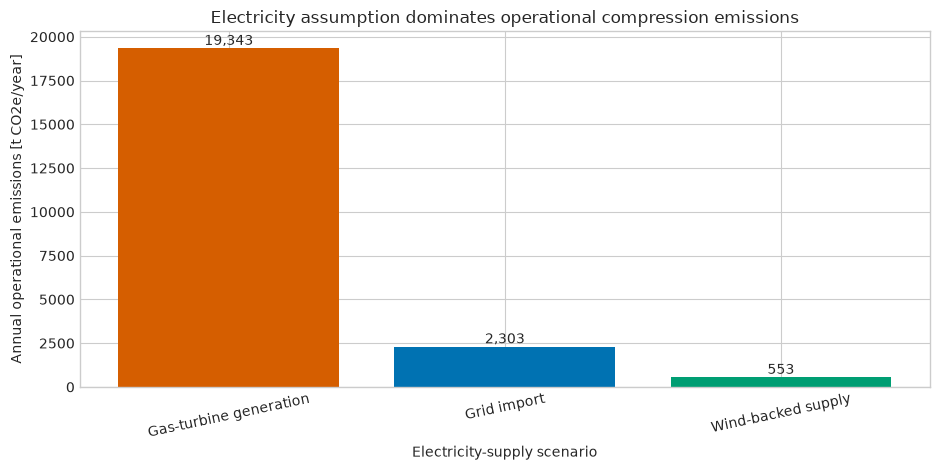

In [22]:
figure, axis = plt.subplots(figsize=(9.5, 4.8))

axis.bar(
    electricity_scenarios["electricity_source"],
    electricity_scenarios["annual_emissions_t_co2e"],
    color=[COLORS["red"], COLORS["blue"], COLORS["green"]],
)
axis.set_title("Electricity assumption dominates operational compression emissions")
axis.set_xlabel("Electricity-supply scenario")
axis.set_ylabel("Annual operational emissions [t CO2e/year]")
axis.tick_params(axis="x", rotation=12)

for index, value in enumerate(
    electricity_scenarios["annual_emissions_t_co2e"]
):
    axis.text(
        index,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
    )

figure.tight_layout()
plt.show()


## 8. Final application: reusable evidence-to-design workflow

The end-to-end workflow is now reproducible:

1. replace the embedded planning rows with a dated public-data extract;
2. retain provenance, units, transformations, and confidence flags;
3. calculate weighted statistics without treating correlation as causality;
4. use NeqSim standard density to convert volume to mass;
5. configure and execute a connected export-compression process;
6. retrieve power, cooling duty, phase products, and mass closure;
7. vary pressure, regional scale, and electricity assumptions; and
8. distinguish statistical uncertainty from thermodynamic-model uncertainty.

The function can be reused with another composition, EOS, flow scale, pressure target,
or aftercooler temperature after those inputs are independently qualified.


In [23]:
assert confidence_interval[0] < weighted_intensity < confidence_interval[1]
assert 1.0 / len(planning_data) <= hhi <= 1.0
assert np.all(np.diff(pressure_results["power_kw"]) > 0.0)
assert np.all(np.diff(pressure_results["specific_power_kwh_sm3"]) > 0.0)
assert pressure_results["mass_residual"].abs().max() < 1.0e-10
assert regional_results["mass_residual"].abs().max() < 1.0e-10

power_flow_slope = np.polyfit(
    regional_results["flow_msm3_day"],
    regional_results["power_mw"],
    deg=1,
)
predicted_power = np.polyval(
    power_flow_slope,
    regional_results["flow_msm3_day"],
)
linear_scaling_error = np.max(
    np.abs(predicted_power - regional_results["power_mw"])
) / regional_results["power_mw"].max()

assert linear_scaling_error < 1.0e-8
assert electricity_scenarios["annual_emissions_t_co2e"].gt(0.0).all()
assert (
    electricity_scenarios["annual_emissions_t_co2e"].iloc[-1]
    < electricity_scenarios["annual_emissions_t_co2e"].iloc[0]
)

validation_summary = pd.DataFrame(
    {
        "Validation": [
            "Data-quality gates",
            "Weighted statistics",
            "NeqSim standard properties",
            "Base process mass closure",
            "Pressure trend",
            "Regional linear scaling",
            "Electricity-emissions ordering",
        ],
        "Status": ["Passed"] * 7,
    }
)
display(validation_summary)
print(f"Maximum linear-scaling error: {linear_scaling_error:.2e}")


Maximum linear-scaling error: 2.56e-15


,Validation,Status
0,Data-quality gates,Passed
1,Weighted statistics,Passed
2,NeqSim standard properties,Passed
3,Base process mass closure,Passed
4,Pressure trend,Passed
5,Regional linear scaling,Passed
6,Electricity-emissions ordering,Passed


## Limitations and applicability

- The regional table is a teaching scenario, not a current statistical release.
- Broad regional averages hide country, asset, contractual, and seasonal variation.
- The bootstrap captures resampling sensitivity only; it excludes systematic bias.
- SRK is used for a dry screening gas. Wet, sour, hydrogen-rich, or dense-phase cases
  require a qualified fluid model and binary-interaction parameters.
- The compressor is a steady-state thermodynamic model without a vendor map, driver,
  antisurge system, piping pressure drop, or mechanical limits.
- Electricity factors are illustrative and must be replaced by project-specific,
  temporal, and boundary-consistent values.
- Results support screening and teaching, not investment approval or equipment
  procurement.


## Troubleshooting

- If a public URL changes, use the embedded dataset to run the notebook and repair the
  extraction separately; do not silently substitute a different source.
- If component names fail, use NeqSim's canonical names shown in this notebook.
- If a process case does not converge, check composition sum, units, pressure ordering,
  and phase state before changing solver tolerances.
- A positive cooler duty indicates a sign-convention or specification mistake here;
  this tutorial expects heat removal to be negative.
- A nonzero mass residual usually indicates an omitted phase product or stale stream.
  Rebuild a fresh process for every scenario.


## Further exercises

1. Download a dated Our World in Data energy CSV and reproduce the data contract.
2. Compare volume-weighted and population-weighted intensity results.
3. Replace the dry gas with a CO₂-rich or hydrogen-blended composition and qualify the
   thermodynamic model.
4. Add two-stage compression with equal pressure ratios and intercooling.
5. Introduce a compressor map and flag operating points outside the qualified envelope.
6. Propagate statistical input distributions through process power with Monte Carlo
   sampling.
7. Replace annual electricity factors with an hourly power-system time series.


## Summary

This notebook turns a previously empty statistical-resource page into a complete
statistics-to-engineering workflow. It preserves the original links and video, makes
the teaching data contract explicit, calculates weighted and uncertainty metrics,
constructs a real SRK gas model, translates standard volume into mass flow, executes a
connected NeqSim compression process, closes the mass balance, and screens pressure,
scale, and electricity scenarios.


## Authoritative references

- [Our World in Data — Energy](https://ourworldindata.org/energy)
- [Energy Institute — Statistical Review resources](https://www.energyinst.org/statistical-review/resources-and-data-downloads)
- [Eurostat — Energy database](https://ec.europa.eu/eurostat/web/energy/database)
- [Statistics Norway — Energy](https://www.ssb.no/en/energi-og-industri/energi)
- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim process equipment documentation](https://equinor.github.io/neqsim/process/equipment/)
- [ISO 6976:2016 overview](https://www.iso.org/standard/55842.html)
- [GHG Protocol standards and guidance](https://ghgprotocol.org/standards-guidance)

Accessed for notebook verification on 2026-07-27. Always retain the publication date
and licence of any dataset substituted for the embedded planning scenario.
